# TCGA Mutation Frequency & Driver-Gene Labeling

1. Downloads somatic mutation (MAF) files from the GDC API for a set of TCGA cancer types
2. Computes per-gene mutation frequency across samples
3. Visualizes the mutation frequency distribution, overall and per cancer type
4. Builds a driver vs. non-driver gene label set, filtered by:
   - Known driver genes (COSMIC Cancer Gene Census)
   - Low mutation frequency in TCGA
   - Exclusion of genes in cancer-related Reactome pathways


## 1. Imports and Configuration

In [1]:
from pathlib import Path
import os
import random
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from typing import List, Tuple, Set

In [2]:
DATA_DIR = Path("data/tcga_maf")
OUTPUT_DIR = Path("data")
OUTPUT_FILE = OUTPUT_DIR / "mutation_frequency_tcga.csv"

# CANCER_TYPES = [
#     "BRCA","LUAD","LUSC","HNSC",
#     "KIRC","KIRP","PRAD","THCA",
#     "STAD","ESCA","COAD","READ",
#     "LIHC","UCEC","BLCA","CESC",
#     "SKCM","OV","LAML","GBM",
#     "LGG","SARC","PAAD","PCPG"
# ]

CANCER_TYPES = [
    "BRCA","LUAD"
]


GDC_API_FILES = "https://api.gdc.cancer.gov/files"
GDC_API_DATA = "https://api.gdc.cancer.gov/data"

## 2. GDC MAF Download

Query the GDC API for MAF file IDs per project and download them locally. This version adds
request timeouts, HTTP status checks, and atomic writes (download to a `.tmp` file, then rename)
so a failed/interrupted download never leaves a corrupt MAF file behind.

In [3]:
def get_maf_file_ids(project: str, size: int = 200):
    params = {
        "filters": {
            "op": "and",
            "content": [
                {
                    "op": "in",
                    "content": {
                        "field": "cases.project.project_id",
                        "value": [f"TCGA-{project}"]
                    }
                },
                {
                    "op": "in",
                    "content": {
                        "field": "data_type",
                        "value": ["Masked Somatic Mutation"]
                    }
                }
            ]
        },
        "fields": "file_id,file_name",
        "format": "JSON",
        "size": size
    }

    response = requests.post(
        GDC_API_FILES,
        json=params,
        headers={"Content-Type": "application/json"},
        timeout=30
    )

    if response.status_code != 200:
        raise RuntimeError(f"GDC request failed: {response.status_code}")

    data = response.json()
    hits = data.get("data", {}).get("hits", [])

    return [(f["file_id"], f["file_name"]) for f in hits]

In [4]:
def download_maf_files(file_ids, project):
    project_dir = DATA_DIR / project
    project_dir.mkdir(parents=True, exist_ok=True)

    for file_id, file_name in file_ids:
        file_path = project_dir / file_name
        tmp_path = file_path.with_suffix(".tmp")

        if file_path.exists():
            print(f"[SKIP] {file_name}")
            continue

        url = f"{GDC_API_DATA}/{file_id}"
        print(f"[DOWNLOAD] {file_name}")

        try:
            r = requests.get(url, stream=True, timeout=60)

            if r.status_code != 200:
                print(f"[ERROR] Failed {file_id} ({r.status_code})")
                continue

            with open(tmp_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

            tmp_path.rename(file_path)

        except requests.exceptions.RequestException as e:
            print(f"[ERROR] {file_name}: {e}")
            if tmp_path.exists():
                tmp_path.unlink()

## 3. MAF Processing

Read each MAF file for a cancer type, keeping only the `Hugo_Symbol` and `Tumor_Sample_Barcode`
columns, and collect the set of unique (gene, sample) mutation pairs.

In [5]:
def process_maf(cancer_dir):
    gene_sample_pairs = set()
    sample_set = set()

    for maf_file in cancer_dir.rglob("*.maf*"):
        try:
            print(f"[PROCESS] {maf_file.name}")

            df = pd.read_csv(
                maf_file,
                sep="\t",
                comment="#",
                usecols=["Hugo_Symbol", "Tumor_Sample_Barcode"],
                dtype={"Hugo_Symbol": str, "Tumor_Sample_Barcode": str},
                compression="infer"
            )

            df = df.dropna().drop_duplicates()

            pairs = set(zip(df["Hugo_Symbol"], df["Tumor_Sample_Barcode"]))
            gene_sample_pairs.update(pairs)
            sample_set.update(df["Tumor_Sample_Barcode"])

        except Exception as e:
            print(f"[ERROR] {maf_file}: {e}")
            continue

    print(f"[SUMMARY] {len(gene_sample_pairs)} gene-sample pairs, {len(sample_set)} samples")

    return gene_sample_pairs, sample_set

## 4. Compute Mutation Frequency per Cancer Type

In [6]:
def compute_mutation_frequency(cancer, cancer_dir):
    gene_sample_pairs, sample_set = process_maf(cancer_dir)
    gene_counts = defaultdict(int)

    for gene, sample in gene_sample_pairs:
        gene_counts[gene] += 1

    num_samples = len(sample_set)
    results = []

    for gene, count in gene_counts.items():
        results.append({
            "gene": gene,
            "mutation_frequency": count / num_samples if num_samples > 0 else 0
        })

    return pd.DataFrame(results)

### Run for all cancer types

Downloads MAF files for every project in `CANCER_TYPES`, computes mutation frequency for
each, and concatenates the results into a single CSV. Requires network access to the GDC API —
run this cell only when you're ready to fetch real data (it can take a while for 24 cancer
types).

In [7]:
all_df = []

for cancer in CANCER_TYPES:
    try:
        print(f"\n[PROCESSING] {cancer}")

        ids = get_maf_file_ids(cancer)
        print(f"[INFO] {len(ids)} files found")

        download_maf_files(ids, cancer)

        df = compute_mutation_frequency(cancer, DATA_DIR / cancer)

        if df is None or df.empty:
            print(f"[WARNING] No data for {cancer}")
            continue

        df["cancer_type"] = cancer

        print(f"[INFO] {cancer}: {df.shape}")
        all_df.append(df)

    except Exception as e:
        print(f"[ERROR] {cancer}: {e}")
        continue

# Final aggregation
if len(all_df) == 0:
    raise RuntimeError("No mutation data collected")

mutation_df = pd.concat(all_df, ignore_index=True)

mutation_df.to_csv(OUTPUT_FILE, index=False)

print("[DONE] Saved:", OUTPUT_FILE)
print(mutation_df.head())


[PROCESSING] BRCA
[INFO] 200 files found
[SKIP] e35fa380-07ac-45e1-9adc-4351675c6ccf.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ac3dbb7f-2ce9-43b7-9f45-1c1521e6bbf5.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] a329335e-2962-485d-af32-1f6adf48cf7f.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] fe1694df-4aca-4a23-bbf5-c0c1d24d4c2b.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] c107d4de-6001-4027-a7f1-7c03d484ddaf.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] 0b8a9b96-d855-482b-97bd-a45ff5a20468.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] aa89b021-ab84-4c79-9624-e4831aa87df7.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] f02cebd5-5840-4c63-bdf2-af7677e112e9.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] 1f5ddd2c-04c3-4805-85fa-de57a9e5a76d.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] 5c132854-804e-40cc-a6db-3252ebd928ef.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ef383034-1e77-4dc9-9283-357f7cb1549e.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ba72ca40-e70d-4d30-93fc-ac988b041d52.wxs.aliquot_ensemble_masked.maf.gz
[SKIP] ed6

## 5. Explore Mutation Frequency Results

Load the saved CSV and visualize the distribution of mutation frequencies, both overall and
broken down by cancer type, plus the top mutated genes per cancer type.

In [8]:
df = pd.read_csv("data/mutation_frequency_tcga.csv")
df.head()

,gene,mutation_frequency,cancer_type
0,RIN1,0.002747,BRCA
1,INCA1,0.002747,BRCA
2,ADGRE3,0.019231,BRCA
3,RALGAPA2,0.019231,BRCA
4,NCOR1,0.057692,BRCA


### 5.1 Overall mutation frequency distribution (log scale)

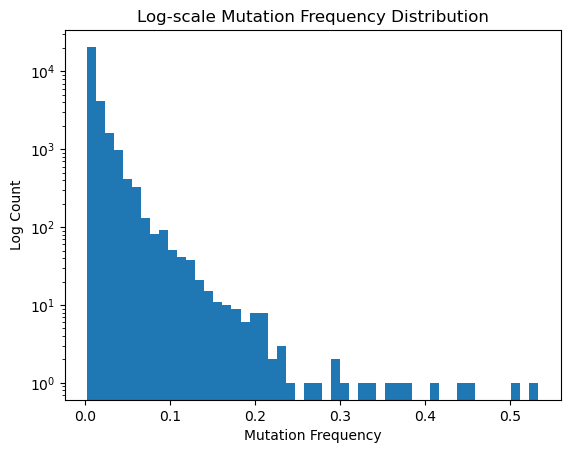

In [9]:
plt.figure()
plt.hist(df["mutation_frequency"] + 1e-6, bins=50)
plt.yscale("log")
plt.xlabel("Mutation Frequency")
plt.ylabel("Log Count")
plt.title("Log-scale Mutation Frequency Distribution")
plt.show()

### 5.2 Mutation frequency distribution per cancer type (overlaid)

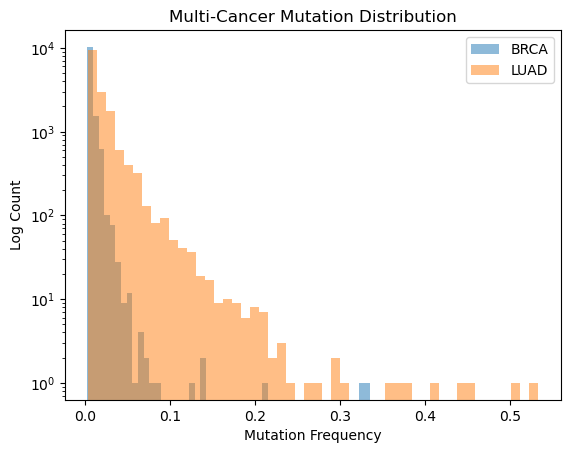

In [10]:
if "cancer_type" in df.columns:
    cancers = df["cancer_type"].unique()

    plt.figure()
    for cancer in cancers:
        subset = df[df["cancer_type"] == cancer]["mutation_frequency"]
        plt.hist(subset + 1e-6, bins=50, alpha=0.5, label=cancer)

    plt.yscale("log")
    plt.xlabel("Mutation Frequency")
    plt.ylabel("Log Count")
    plt.title("Multi-Cancer Mutation Distribution")
    plt.legend()
    plt.show()
else:
    print("No cancer_type column found.")

### 5.3 Top 10 most frequently mutated genes, per cancer type

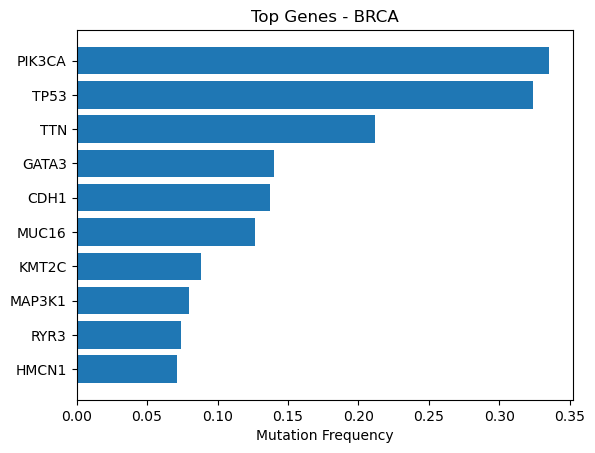

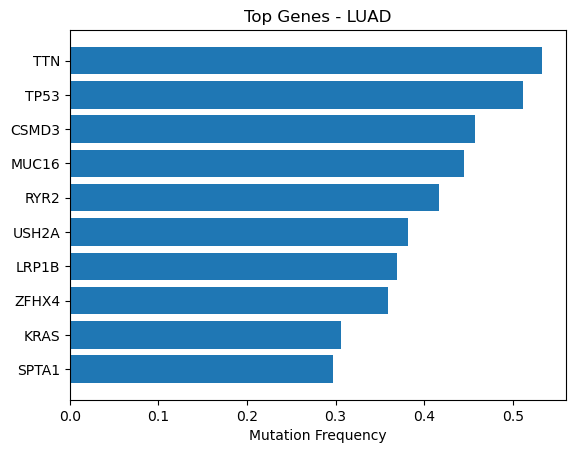

In [11]:
if "cancer_type" in df.columns:
    for cancer in df["cancer_type"].unique():
        sub = df[df["cancer_type"] == cancer]
        top = sub.sort_values("mutation_frequency", ascending=False).head(10)

        plt.figure()
        plt.barh(top["gene"], top["mutation_frequency"])
        plt.gca().invert_yaxis()
        plt.title(f"Top Genes - {cancer}")
        plt.xlabel("Mutation Frequency")
        plt.show()
else:
    print("No cancer_type column found.")

## 6. Driver vs. Non-Driver Gene Labeling

Builds the gene universe from GENCODE, identifies known driver genes from COSMIC's Cancer Gene Census,
and filters candidate non-driver genes by mutation frequency (using the CSV produced above) and
cancer pathway membership.

In [12]:
USE_MUTATION_FILTER = True
USE_PATHWAY_FILTER = True
USE_DEGREE_MATCH = True
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

### 6.1 Build the gene universe from GENCODE annotation

In [13]:
gtf_file = "../data/gencode.v49.basic.annotation.gtf"

genes = set()

with open(gtf_file, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue

        fields = line.strip().split("\t")

        if len(fields) < 9 or fields[2] != "gene":
            continue

        info = fields[8]

        gene_name = None
        gene_type = None

        for item in info.split(";"):
            item = item.strip()
            if item.startswith("gene_name"):
                gene_name = item.split('"')[1]
            elif item.startswith("gene_type"):
                gene_type = item.split('"')[1]

        if gene_name and gene_type == "protein_coding":
            genes.add(gene_name)

gencode_df = pd.DataFrame(sorted(genes), columns=["gene_name"])
gencode_df.to_csv("data/gencode_genes.csv", index=False)

print(f"✅ GENCODE genes (protein-coding only): {len(genes)}")

✅ GENCODE genes (protein-coding only): 20070


** Parses the GENCODE v49 GTF annotation, keeps only lines where the
feature type is `"gene"`, and extracts `gene_name` from the attributes field into the "gene
universe" used for the rest of the labeling pipeline.

### 6.2 Load driver genes (COSMIC Cancer Gene Census) and compute raw non-drivers

In [14]:
all_genes = set(pd.read_csv("data/gencode_genes.csv")["gene_name"])

cgc = pd.read_csv("../data/Census_allWed.tsv", sep="\t")
driver_genes = set(cgc["Symbol"].dropna())

print(f"Driver genes: {len(driver_genes)}")

non_drivers = all_genes - driver_genes
print(f"Raw non-drivers: {len(non_drivers)}")

Driver genes: 763
Raw non-drivers: 19326


** Loads the COSMIC Cancer Gene Census (`Census_allWed.tsv`) as the
set of known driver genes, and computes `non_drivers` as everything in the GENCODE gene universe
that isn't a CGC driver.

### 6.3 Apply mutation-frequency filter

Remove non-driver candidates with mutation frequency ≥ 1% in TCGA.

In [15]:
if USE_MUTATION_FILTER:
    mutation_df = pd.read_csv("../data/mutation_frequency_tcga.csv")

    # Max frequency observed per gene across all cancer types
    max_freq_per_gene = mutation_df.groupby("gene")["mutation_frequency"].max()

    before = len(non_drivers)
    non_drivers = {
        g for g in non_drivers
        if max_freq_per_gene.get(g, 0.0) < 0.01
    }
    print(f"After mutation filter: {len(non_drivers)} (-{before - len(non_drivers)})")

After mutation filter: 18405 (-921)


Loads the mutation frequency CSV, builds the set of genes with
frequency `< 0.01` (1%) across TCGA, and **intersects** it with `non_drivers` — keeping only
non-driver candidates that are rarely mutated.

### 6.4 Build disease-pathway gene set from Reactome (hierarchy-restricted)

Using `ReactomePathwaysRelation` (parent → child pathway links) to restrict the gene set to pathways that are descendants of the top-level **Disease** pathway (`R-HSA-1643685`), via graph traversal with `networkx`.

In [16]:
relations_file = "../data/reactome/reactome_relations.csv"
reactome_file = "../data/reactome/ReactomePathways.gmt"

DISEASE_ROOT = "R-HSA-1643685"  # top-level "Disease" pathway

# 1. Build the pathway hierarchy as a directed graph (parent -> child)
relations_df = pd.read_csv(relations_file)

G = nx.DiGraph()
G.add_edges_from(
    zip(relations_df["reactome_id_1"], relations_df["reactome_id_2"])
)

# 2. Find every pathway ID that is a descendant of the Disease root
if DISEASE_ROOT in G:
    disease_pathway_ids = nx.descendants(G, DISEASE_ROOT)
    disease_pathway_ids.add(DISEASE_ROOT)
else:
    raise ValueError(f"{DISEASE_ROOT} not found in relations file")

print(f"Disease-related pathway IDs: {len(disease_pathway_ids)}")

# 3. Walk the GMT file, but only keep genes from pathways in that descendant set
genes = set()
kept_pathways = 0
skipped_pathways = 0

with open(reactome_file) as f:
    for line in f:
        parts = line.strip().split("\t")

        if len(parts) < 3:
            continue

        pathway_name = parts[0]
        pathway_id = parts[1]
        pathway_genes = parts[2:]

        if pathway_id in disease_pathway_ids:
            genes.update(pathway_genes)
            kept_pathways += 1
        else:
            skipped_pathways += 1

print(f"Kept {kept_pathways} disease-related pathways, skipped {skipped_pathways} unrelated pathways")

df_pathway = pd.DataFrame(sorted(genes), columns=["gene"])
df_pathway.to_csv("data/cancer_pathway_genes.csv", index=False)

print(f"Saved {len(genes)} disease-pathway genes")

Disease-related pathway IDs: 782
Kept 782 disease-related pathways, skipped 2048 unrelated pathways
Saved 2505 disease-pathway genes


### 6.5 Apply pathway filter

Exclude non-driver candidates that belong to any disease-related Reactome pathway (descendants of the Disease root), now correctly gated by `USE_PATHWAY_FILTER`.

In [17]:
if USE_PATHWAY_FILTER:
    pathway_df = pd.read_csv("data/cancer_pathway_genes.csv")

    cancer_pathway_genes = set(pathway_df["gene"])

    before = len(non_drivers)
    non_drivers = non_drivers - cancer_pathway_genes
    print(f"After pathway filter: {len(non_drivers)} (-{before - len(non_drivers)})")
else:
    print("Pathway filter skipped (USE_PATHWAY_FILTER=False)")

After pathway filter: 16743 (-1662)


### 6.6 Build and save the labeled gene table

In [18]:
labels = []

for g in driver_genes:
    labels.append((g, 1))

for g in non_drivers:
    labels.append((g, 0))

labels_df = pd.DataFrame(labels, columns=["gene", "label"])

print(labels_df["label"].value_counts())

output_path = "data/processed/gene_labels_driver_vs_nondriver.csv"
os.makedirs("data/processed", exist_ok=True)
labels_df.to_csv(output_path, index=False)

print(f"\u2705 Saved \u2192 {output_path}")

label
0    16743
1      763
Name: count, dtype: int64
✅ Saved → data/processed/gene_labels_driver_vs_nondriver.csv


### 6.7 Save driver / non-driver gene lists as plain text files

In [19]:
driver_path = os.path.join("data/processed", "driver_genes.txt")
with open(driver_path, "w") as f:
    for gene in driver_genes:
        f.write(f"{gene}\n")

nondriver_path = os.path.join("data/processed", "non_driver_genes.txt")
with open(nondriver_path, "w") as f:
    for gene in non_drivers:
        f.write(f"{gene}\n")

print(f"\u2705 Saved driver genes \u2192 {driver_path}")
print(f"\u2705 Saved non-driver genes \u2192 {nondriver_path}")

✅ Saved driver genes → data/processed/driver_genes.txt
✅ Saved non-driver genes → data/processed/non_driver_genes.txt


## 7. Validation & Additional Analysis

Successfully running (20,070 protein-coding genes → 763 drivers / 16,743 non-drivers
after filtering). The cells below **check** those results rather than take them on faith:
- no gene ends up labeled both driver and non-driver, and the counts add up
- driver genes are actually mutated more often than non-drivers (the basic sanity check a
  driver/non-driver label set needs to pass before it's trustworthy for downstream modeling)
- a filter funnel showing how many genes each filtering stage removed
- a class-imbalance chart to accompany the note added earlier


In [20]:
# =====================================================
# 7.1 Sanity checks
# =====================================================

# 1. No gene should be labeled both driver and non-driver
overlap = driver_genes & non_drivers
assert len(overlap) == 0, f"{len(overlap)} genes are labeled both driver and non-driver: {sorted(overlap)[:10]}"
print(f"[OK] No overlap between driver_genes and non_drivers ({len(overlap)} genes in common)")

# 2. labels_df row count should equal driver_genes + non_drivers
expected_rows = len(driver_genes) + len(non_drivers)
assert len(labels_df) == expected_rows, (
    f"labels_df has {len(labels_df)} rows, expected {expected_rows}"
)
print(f"[OK] labels_df row count matches driver_genes + non_drivers ({expected_rows})")

# 3. No duplicate genes in the final label table
dup_genes = labels_df["gene"][labels_df["gene"].duplicated()]
assert dup_genes.empty, f"{len(dup_genes)} duplicate gene(s) in labels_df: {dup_genes.tolist()[:10]}"
print(f"[OK] No duplicate genes in labels_df")

# 4. Every driver gene should actually be in the GENCODE protein-coding universe
# (CGC includes some genes GENCODE's protein-coding filter might not, e.g. non-coding drivers)
drivers_not_in_universe = driver_genes - all_genes
print(
    f"[INFO] {len(drivers_not_in_universe)} driver gene(s) from CGC are not in the "
    f"protein-coding gene universe (likely non-coding drivers, e.g. lncRNA/miRNA cancer genes) "
    f"— this is expected, not a bug."
)


[OK] No overlap between driver_genes and non_drivers (0 genes in common)
[OK] labels_df row count matches driver_genes + non_drivers (17506)
[OK] No duplicate genes in labels_df
[INFO] 19 driver gene(s) from CGC are not in the protein-coding gene universe (likely non-coding drivers, e.g. lncRNA/miRNA cancer genes) — this is expected, not a bug.


Driver genes  — median max mutation frequency: 0.004040404040404
Non-drivers   — median max mutation frequency: 0.002020202020202

Mann-Whitney U test (drivers > non-drivers): U=9051606.5, p=6.497e-88
[OK] Driver genes are significantly more mutated than non-drivers, as expected.


/var/folders/z_/4_txl3tn61g8nprq0_s7tsbc0000gn/T/ipykernel_15901/82426101.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


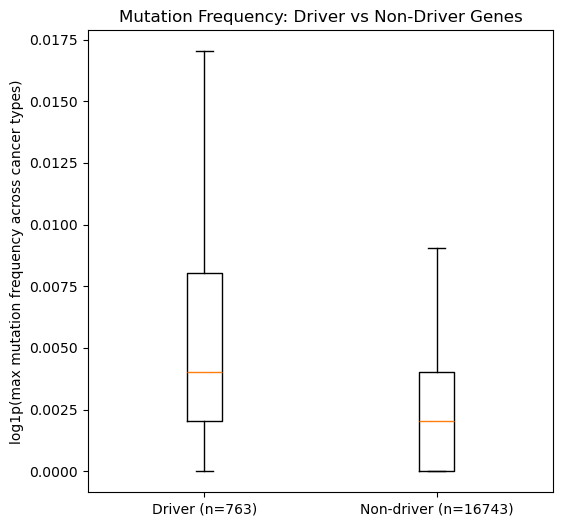

In [21]:
# =====================================================
# 7.2 Do driver genes actually get mutated more often?
# This is the core validity check for the label set: if drivers and
# non-drivers show similar mutation-frequency distributions, the
# labels aren't capturing a meaningful biological signal.
# =====================================================

from scipy import stats

driver_freqs = max_freq_per_gene.reindex(list(driver_genes)).fillna(0.0)
non_driver_freqs = max_freq_per_gene.reindex(list(non_drivers)).fillna(0.0)

print("Driver genes  — median max mutation frequency:", driver_freqs.median())
print("Non-drivers   — median max mutation frequency:", non_driver_freqs.median())

# Mann-Whitney U test (one-sided: drivers > non-drivers), since frequencies
# are heavily right-skewed and not normally distributed
u_stat, p_value = stats.mannwhitneyu(
    driver_freqs, non_driver_freqs, alternative="greater"
)
print(f"\nMann-Whitney U test (drivers > non-drivers): U={u_stat:.1f}, p={p_value:.3e}")

if p_value < 0.05:
    print("[OK] Driver genes are significantly more mutated than non-drivers, as expected.")
else:
    print("[WARNING] No significant difference found — investigate before using these labels.")

# Boxplot on a log scale (log1p to handle the many zero-frequency non-drivers)
plt.figure(figsize=(6, 6))
plt.boxplot(
    [np.log1p(driver_freqs), np.log1p(non_driver_freqs)],
    labels=["Driver (n={})".format(len(driver_freqs)), "Non-driver (n={})".format(len(non_driver_freqs))],
    showfliers=False,
)
plt.ylabel("log1p(max mutation frequency across cancer types)")
plt.title("Mutation Frequency: Driver vs Non-Driver Genes")
plt.show()


[OK] Recomputed funnel matches the pipeline's final non_drivers set.


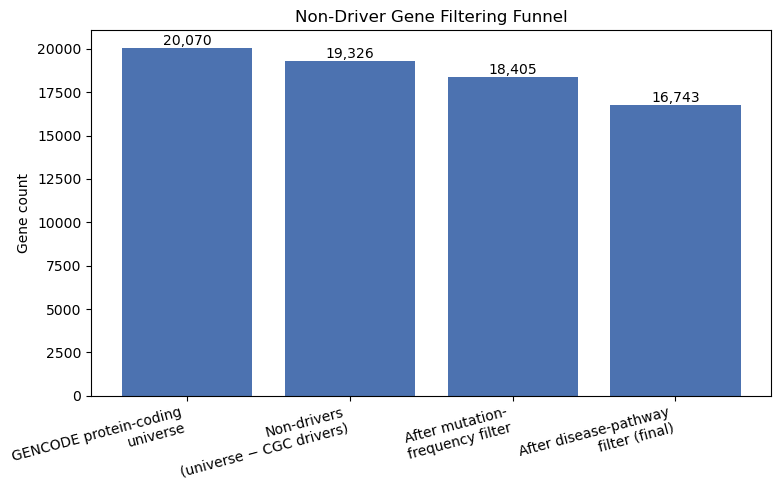

In [22]:
# =====================================================
# 7.3 Filter funnel: how many genes each stage removed
# Fully recomputed from the sets already in memory, so it reflects
# exactly what the pipeline above produced (no hardcoded numbers).
# =====================================================

raw_non_drivers = all_genes - driver_genes

after_mutation_filter = {
    g for g in raw_non_drivers
    if max_freq_per_gene.get(g, 0.0) < 0.01
} if USE_MUTATION_FILTER else raw_non_drivers

after_pathway_filter = (
    after_mutation_filter - cancer_pathway_genes
    if USE_PATHWAY_FILTER else after_mutation_filter
)

assert after_pathway_filter == non_drivers, (
    "Recomputed final non-driver set doesn't match `non_drivers` from the pipeline above — "
    "check that USE_MUTATION_FILTER/USE_PATHWAY_FILTER weren't changed between cells."
)
print("[OK] Recomputed funnel matches the pipeline's final non_drivers set.")

funnel_stages = [
    ("GENCODE protein-coding\nuniverse", len(all_genes)),
    ("Non-drivers\n(universe − CGC drivers)", len(raw_non_drivers)),
    ("After mutation-\nfrequency filter", len(after_mutation_filter)),
    ("After disease-pathway\nfilter (final)", len(after_pathway_filter)),
]

fig, ax = plt.subplots(figsize=(8, 5))
labels_ = [s[0] for s in funnel_stages]
counts_ = [s[1] for s in funnel_stages]
bars = ax.bar(labels_, counts_, color="#4C72B0")
for bar, count in zip(bars, counts_):
    ax.text(bar.get_x() + bar.get_width() / 2, count, f"{count:,}", ha="center", va="bottom")
ax.set_ylabel("Gene count")
ax.set_title("Non-Driver Gene Filtering Funnel")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


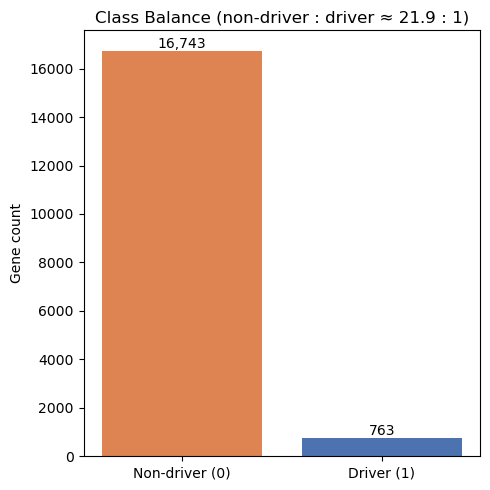

Class imbalance ratio (non-driver:driver): 21.94 : 1
This is the imbalance flagged in the Analysis Summary at the top of the notebook — worth addressing via metric choice (e.g. AUPRC), class weighting, or resampling downstream, not something this cleanup pass changes.


In [23]:
# =====================================================
# 7.4 Class imbalance chart
# =====================================================

counts = labels_df["label"].value_counts().sort_index()
ratio = counts[0] / counts[1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["Non-driver (0)", "Driver (1)"], counts.values, color=["#DD8452", "#4C72B0"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("Gene count")
ax.set_title(f"Class Balance (non-driver : driver ≈ {ratio:.1f} : 1)")
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (non-driver:driver): {ratio:.2f} : 1")
print(
    "This is the imbalance flagged in the Analysis Summary at the top of the notebook — "
    "worth addressing via metric choice (e.g. AUPRC), class weighting, or resampling "
    "downstream, not something this cleanup pass changes."
)
